In [2]:
import pandas as pd

# Adjust your username if needed
df = pd.read_csv('df_clean_integrated.csv', low_memory=False)

df.head()

,CRASH DATE,CRASH TIME,BOROUGH,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,NUMBER OF PERSONS INJURED,...,PERSON_AGE,EJECTION,EMOTIONAL_STATUS,BODILY_INJURY,POSITION_IN_VEHICLE,SAFETY_EQUIPMENT,COMPLAINT,PED_ROLE,PERSON_SEX,YEAR
0,09/11/2021,2:39,BROOKLYN,40.693314,-73.933238,"(40.693314, -73.93323799999999)",WHITESTONE EXPRESSWAY,20 AVENUE,PARKING LOT 110-00 ROCKAWAY BOULEVARD,2,...,29.0,not ejected,conscious,0,driver,lap belt,complaint of pain or nausea,driver,m,2021.0
1,09/11/2021,2:39,BROOKLYN,40.693314,-73.933238,"(40.693314, -73.93323799999999)",WHITESTONE EXPRESSWAY,20 AVENUE,PARKING LOT 110-00 ROCKAWAY BOULEVARD,2,...,36.0,missing,missing,0,missing,missing,missing,registrant,missing,2021.0
2,09/11/2021,2:39,BROOKLYN,40.693314,-73.933238,"(40.693314, -73.93323799999999)",WHITESTONE EXPRESSWAY,20 AVENUE,PARKING LOT 110-00 ROCKAWAY BOULEVARD,2,...,25.0,missing,missing,0,missing,missing,missing,registrant,m,2021.0
3,09/11/2021,2:39,BROOKLYN,40.693314,-73.933238,"(40.693314, -73.93323799999999)",WHITESTONE EXPRESSWAY,20 AVENUE,PARKING LOT 110-00 ROCKAWAY BOULEVARD,2,...,33.0,not ejected,conscious,0,"front passenger, if two or more persons, inclu...",lap belt,complaint of pain or nausea,passenger,m,2021.0
4,03/26/2022,11:45,BROOKLYN,40.592410,-73.788995,"(40.59241, -73.788995)",QUEENSBORO BRIDGE UPPER,HORACE HARDING EXPRESSWAY,PARKING LOT 110-00 ROCKAWAY BOULEVARD,1,...,28.0,not ejected,conscious,0,driver,lap belt & harness,complaint of pain or nausea,driver,f,2022.0


In [4]:
df.columns.tolist()


['CRASH DATE',
 'CRASH TIME',
 'BOROUGH',
 'LATITUDE',
 'LONGITUDE',
 'LOCATION',
 'ON STREET NAME',
 'CROSS STREET NAME',
 'OFF STREET NAME',
 'NUMBER OF PERSONS INJURED',
 'NUMBER OF PERSONS KILLED',
 'NUMBER OF PEDESTRIANS INJURED',
 'NUMBER OF PEDESTRIANS KILLED',
 'NUMBER OF CYCLIST INJURED',
 'NUMBER OF CYCLIST KILLED',
 'NUMBER OF MOTORIST INJURED',
 'NUMBER OF MOTORIST KILLED',
 'CONTRIBUTING FACTOR VEHICLE 1',
 'COLLISION_ID',
 'VEHICLE TYPE CODE 1',
 'CRASH_DATETIME',
 'LOC_CLUSTER',
 'UNIQUE_ID',
 'CRASH_DATE',
 'CRASH_TIME',
 'PERSON_ID',
 'PERSON_TYPE',
 'PERSON_INJURY',
 'VEHICLE_ID',
 'PERSON_AGE',
 'EJECTION',
 'EMOTIONAL_STATUS',
 'BODILY_INJURY',
 'POSITION_IN_VEHICLE',
 'SAFETY_EQUIPMENT',
 'COMPLAINT',
 'PED_ROLE',
 'PERSON_SEX',
 'YEAR']

In [4]:
df['hour'] = pd.to_datetime(df['CRASH TIME'], format='%H:%M', errors='coerce').dt.hour

# Plot crashes by hour
plt.figure(figsize=(12,6))
df['hour'].value_counts().sort_index().plot(kind='line', marker='o')
plt.title("Crashes by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Crashes")
plt.xticks(range(0,24))
plt.grid(True)
plt.show()

NameError: name 'plt' is not defined

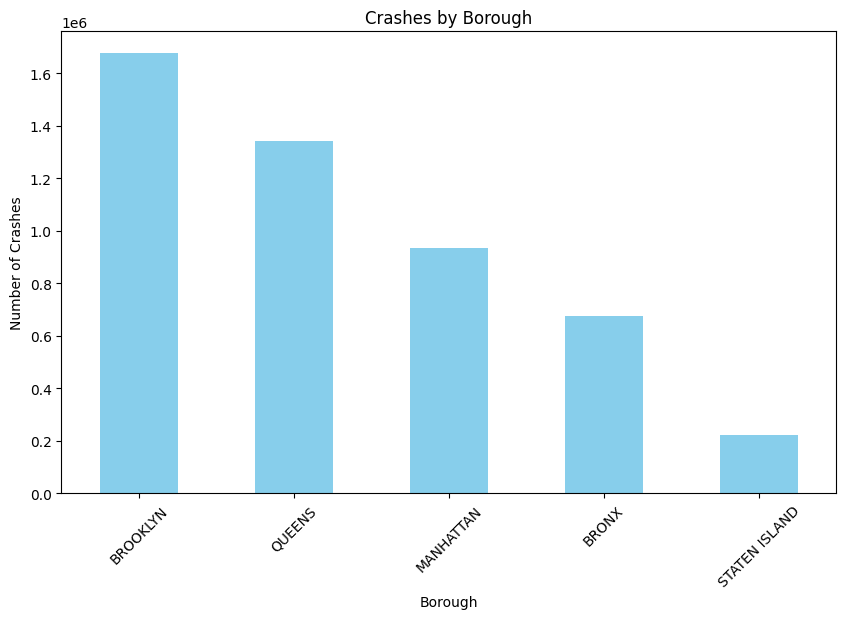

In [6]:
plt.figure(figsize=(10,6))
df['BOROUGH'].value_counts().plot(kind='bar', color='skyblue')
plt.title("Crashes by Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Crashes")
plt.xticks(rotation=45)
plt.show()

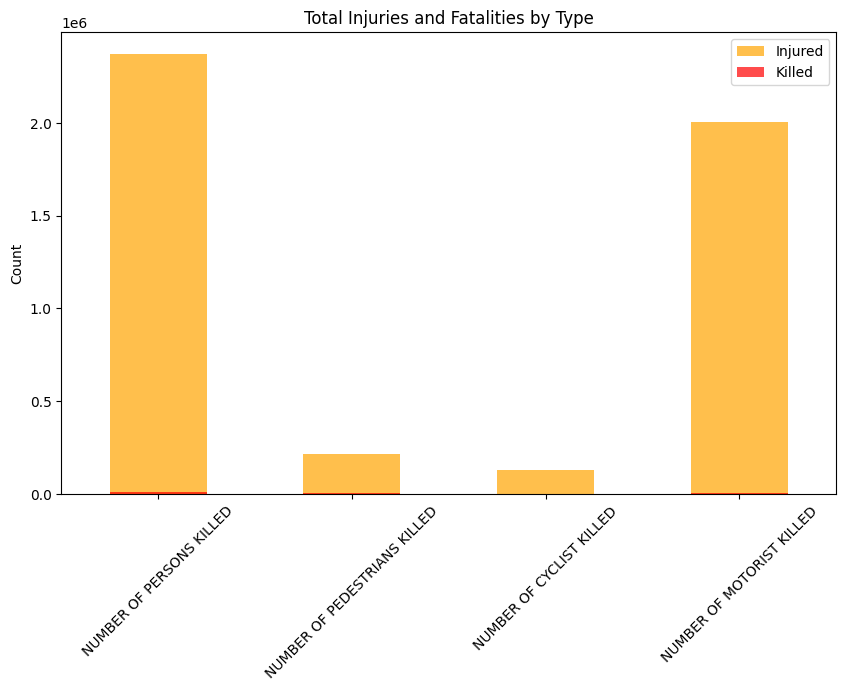

In [7]:
injuries_cols = [
    'NUMBER OF PERSONS INJURED',
    'NUMBER OF PEDESTRIANS INJURED',
    'NUMBER OF CYCLIST INJURED',
    'NUMBER OF MOTORIST INJURED'
]

fatalities_cols = [
    'NUMBER OF PERSONS KILLED',
    'NUMBER OF PEDESTRIANS KILLED',
    'NUMBER OF CYCLIST KILLED',
    'NUMBER OF MOTORIST KILLED'
]

plt.figure(figsize=(10,6))
df[injuries_cols].sum().plot(kind='bar', color='orange', alpha=0.7, label='Injured')
df[fatalities_cols].sum().plot(kind='bar', color='red', alpha=0.7, label='Killed')
plt.title("Total Injuries and Fatalities by Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend()
plt.show()

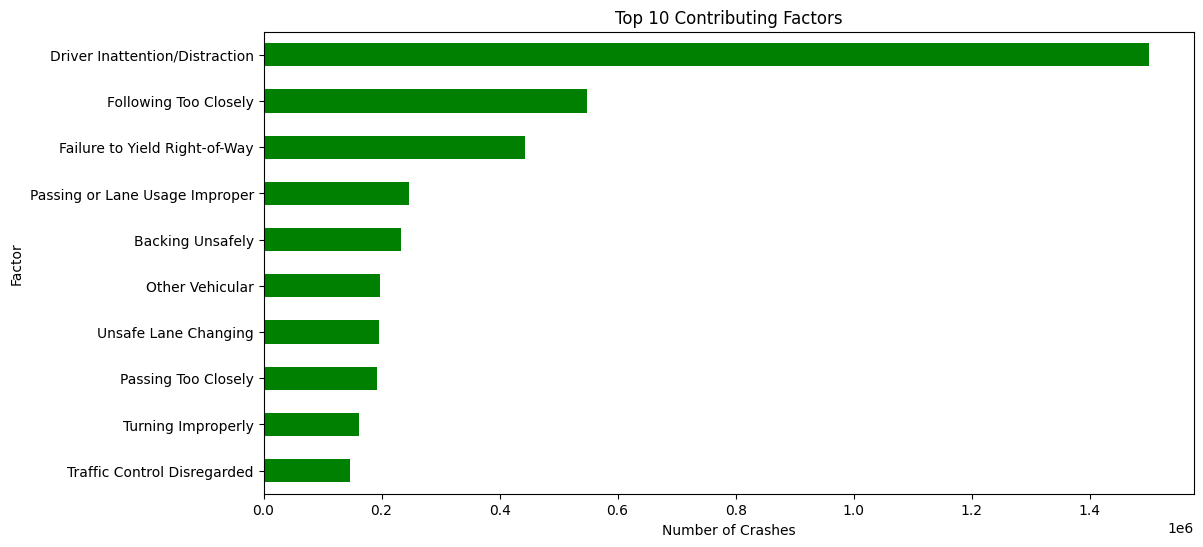

In [8]:
plt.figure(figsize=(12,6))
df['CONTRIBUTING FACTOR VEHICLE 1'].value_counts().head(10).plot(kind='barh', color='green')
plt.title("Top 10 Contributing Factors")
plt.xlabel("Number of Crashes")
plt.ylabel("Factor")
plt.gca().invert_yaxis()  # highest on top
plt.show()

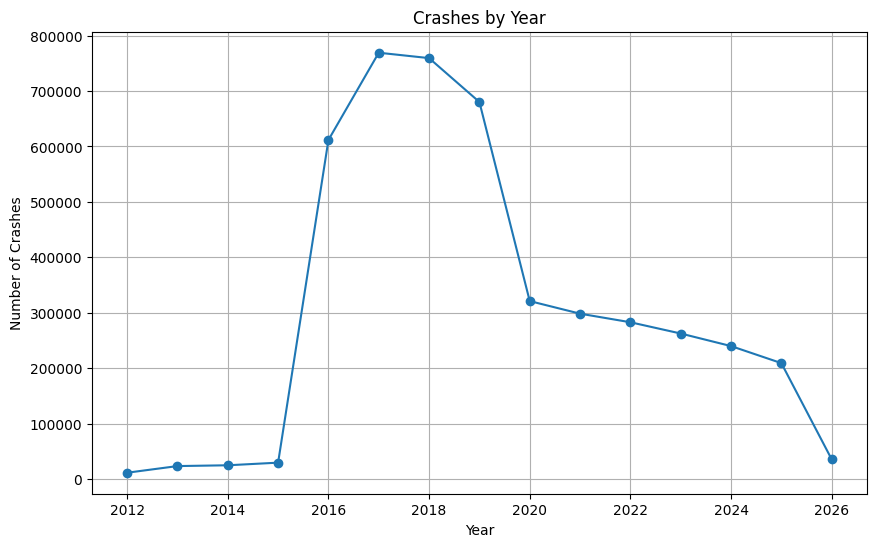

In [9]:
# Ensure YEAR column exists
if 'YEAR' not in df.columns:
    df['YEAR'] = pd.to_datetime(df['CRASH DATE'], errors='coerce').dt.year

plt.figure(figsize=(10,6))
df['YEAR'].value_counts().sort_index().plot(kind='line', marker='o')
plt.title("Crashes by Year")
plt.xlabel("Year")
plt.ylabel("Number of Crashes")
plt.grid(True)
plt.show()

In [5]:
import json

# Calculate real statistics from the complete dataset
print(f"Total collisions: {len(df)}")
print(f"Total injured: {df['NUMBER OF PERSONS INJURED'].sum()}")
print(f"Total killed: {df['NUMBER OF PERSONS KILLED'].sum()}")

# Boroughs
boroughs = df['BOROUGH'].value_counts().to_dict()
print("Boroughs:", boroughs)

# Hours - create if not exists
if 'hour' not in df.columns:
    df['hour'] = pd.to_datetime(df['CRASH TIME'], format='%H:%M', errors='coerce').dt.hour

crashes_by_hour = df['hour'].value_counts().sort_index().to_dict()
crashes_by_hour = {str(int(k)): int(v) for k, v in crashes_by_hour.items() if pd.notna(k)}
print("Sample hours:", dict(list(crashes_by_hour.items())[:5]))

# Injuries by type
injuries_by_type = {
    'pedestrians_injured': int(df['NUMBER OF PEDESTRIANS INJURED'].sum()),
    'cyclists_injured': int(df['NUMBER OF CYCLIST INJURED'].sum()),
    'motorists_injured': int(df['NUMBER OF MOTORIST INJURED'].sum())
}
print("Injuries by type:", injuries_by_type)

# Fatalities by type
fatalities_by_type = {
    'pedestrians_killed': int(df['NUMBER OF PEDESTRIANS KILLED'].sum()),
    'cyclists_killed': int(df['NUMBER OF CYCLIST KILLED'].sum()),
    'motorists_killed': int(df['NUMBER OF MOTORIST KILLED'].sum())
}
print("Fatalities by type:", fatalities_by_type)

# Contributing factors
top_contributing_factors = df['CONTRIBUTING FACTOR VEHICLE 1'].value_counts().head(10).to_dict()
print("Top factors:", list(top_contributing_factors.keys())[:3])

# Years - create if not exists
if 'YEAR' not in df.columns:
    df['YEAR'] = pd.to_datetime(df['CRASH DATE'], errors='coerce').dt.year

crashes_by_year = df['YEAR'].value_counts().sort_index().to_dict()
crashes_by_year = {str(int(k)): int(v) for k, v in crashes_by_year.items() if pd.notna(k)}
print("Years range:", min(crashes_by_year.keys()), "to", max(crashes_by_year.keys()))

# Create metadata
metadata = {
    'total_collisions': len(df),
    'total_injured': int(df['NUMBER OF PERSONS INJURED'].sum()),
    'total_killed': int(df['NUMBER OF PERSONS KILLED'].sum()),
    'boroughs': boroughs,
    'crashes_by_hour': crashes_by_hour,
    'injuries_by_type': injuries_by_type,
    'fatalities_by_type': fatalities_by_type,
    'top_contributing_factors': top_contributing_factors,
    'crashes_by_year': crashes_by_year
}

with open('frontend/public/data/dataset_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Real metadata saved to frontend/public/data/dataset_metadata.json!")

Total collisions: 4849276
Total injured: 2371029
Total killed: 11122.0
Boroughs: {'BROOKLYN': 1675118, 'QUEENS': 1340355, 'MANHATTAN': 933055, 'BRONX': 676882, 'STATEN ISLAND': 223866}
Sample hours: {'0': 181059, '1': 89294, '2': 66613, '3': 58532, '4': 66357}
Injuries by type: {'pedestrians_injured': 213407, 'cyclists_injured': 130343, 'motorists_injured': 2003917}
Fatalities by type: {'pedestrians_killed': 3798, 'cyclists_killed': 898, 'motorists_killed': 6289}
Top factors: ['Driver Inattention/Distraction', 'Following Too Closely', 'Failure to Yield Right-of-Way']
Years range: 2012 to 2026
Real metadata saved to frontend/public/data/dataset_metadata.json!
